In [1]:
# ====================== EMOTION RECOGNITION - GloVe + BiLSTM ======================
# Classification multiclasses des émotions textuelles

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ========================== 1. CHARGEMENT DONNÉES ==========================
import pandas as pd
import numpy as np
import re


train_path = "/kaggle/input/datasets/ahmedgaabi/emotion/train.txt"
val_path = "/kaggle/input/datasets/ahmedgaabi/emotion/val.txt"
test_path = "/kaggle/input/datasets/ahmedgaabi/emotion/test.txt"

def load_emotion_data(path):
    data = pd.read_csv(
        path,
        sep=";",
        header=None,
        names=["text", "label"],
        encoding="utf-8"
    )
    return data

train_data = load_emotion_data(train_path)
val_data = load_emotion_data(val_path)
test_data = load_emotion_data(test_path)

print(train_data.head())
print(train_data["label"].value_counts())

2026-05-22 11:32:11.953174: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779449532.165164      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779449532.225434      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779449532.667575      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779449532.667620      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779449532.667623      57 computation_placer.cc:177] computation placer alr

                                                text    label
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger
label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


In [2]:
label2id = {
    "anger": 0,
    "fear": 1,
    "joy": 2,
    "love": 3,
    "sadness": 4,
    "surprise": 5
}

id2label = {
    0: "anger",
    1: "fear",
    2: "joy",
    3: "love",
    4: "sadness",
    5: "surprise"
}

num_classes = len(label2id)

y_train = train_data["label"].map(label2id).values
y_val = val_data["label"].map(label2id).values
y_test = test_data["label"].map(label2id).values

target_names = [id2label[i] for i in range(num_classes)]

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if 'glove.6B.100d' in filename:
            print(os.path.join(dirname, filename))

/kaggle/input/datasets/danielwillgeorge/glove6b100dtxt/glove.6B.100d.txt


In [4]:
# ========================== 2. GLOVE EMBEDDINGS ==========================
def load_glove_embeddings(glove_path):
    embeddings_index = {}
    with open(glove_path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

# Chemin sur Kag/kaggle/input/datasets/danielwillgeorge/glove6b100dtxtgle
glove_path = '/kaggle/input/datasets/danielwillgeorge/glove6b100dtxt/glove.6B.100d.txt'   # adapte si besoin
embeddings_index = load_glove_embeddings(glove_path)
print(f"{len(embeddings_index)} vecteurs GloVe chargés.")


400000 vecteurs GloVe chargés.


In [5]:
MAX_WORDS = 20000
MAX_LEN = 100
embed_dim = 100

# 1. Créer le tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

# 2. Entraîner le tokenizer sur les textes d'entraînement
tokenizer.fit_on_texts(train_data["text"].astype(str))

# 3. Récupérer le vocabulaire
word_index = tokenizer.word_index

# 4. Définir la taille réelle du vocabulaire
vocab_size = min(MAX_WORDS, len(word_index) + 1)

print("Vocab size:", vocab_size)

# 5. Créer la matrice d'embedding
embedding_matrix = np.zeros((vocab_size, embed_dim))

# 6. Remplir la matrice avec les vecteurs GloVe
for word, i in word_index.items():
    if i >= vocab_size:
        continue

    embedding_vector = embeddings_index.get(word)

    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector[:embed_dim]

print("Matrice d'embedding créée :", embedding_matrix.shape)

# 7. Transformer les textes en séquences
X_train = tokenizer.texts_to_sequences(train_data["text"].astype(str))
X_val = tokenizer.texts_to_sequences(val_data["text"].astype(str))
X_test = tokenizer.texts_to_sequences(test_data["text"].astype(str))

# 8. Padding
X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding="post", truncating="post")
X_val = pad_sequences(X_val, maxlen=MAX_LEN, padding="post", truncating="post")
X_test = pad_sequences(X_test, maxlen=MAX_LEN, padding="post", truncating="post")

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

Vocab size: 15214
Matrice d'embedding créée : (15214, 100)
X_train shape: (16000, 100)
X_val shape: (2000, 100)
X_test shape: (2000, 100)


In [6]:
def build_emotion_model():
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=False
        ),

        Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001))),
        Dropout(0.5),

        Bidirectional(LSTM(32, kernel_regularizer=l2(0.001))),
        Dropout(0.5),

        Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

model = build_emotion_model()
model.summary()

I0000 00:00:1779450802.556242      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779450802.558842      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,521,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,521,400 (5.80 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,521,400 (5.80 MB)

Epoch 1/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.8702 - loss: 0.5317 - val_accuracy: 0.8635 - val_loss: 0.5213
Epoch 2/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8723 - loss: 0.5255 - val_accuracy: 0.8785 - val_loss: 0.4983
Epoch 3/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8729 - loss: 0.5113 - val_accuracy: 0.8905 - val_loss: 0.4605
Epoch 4/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8856 - loss: 0.4792 - val_accuracy: 0.8800 - val_loss: 0.4752
Epoch 5/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8934 - loss: 0.4535 - val_accuracy: 0.8930 - val_loss: 0.4648
Epoch 6/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9032 - loss: 0.4368 - val_accuracy: 0.8895 - val_loss: 0.4383
Epoch 7/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9037 - loss: 0.4209 - val_accuracy: 0.8835 - val_loss: 0.4763
Epoch 8/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9082 - loss: 0.4158 - val_accu

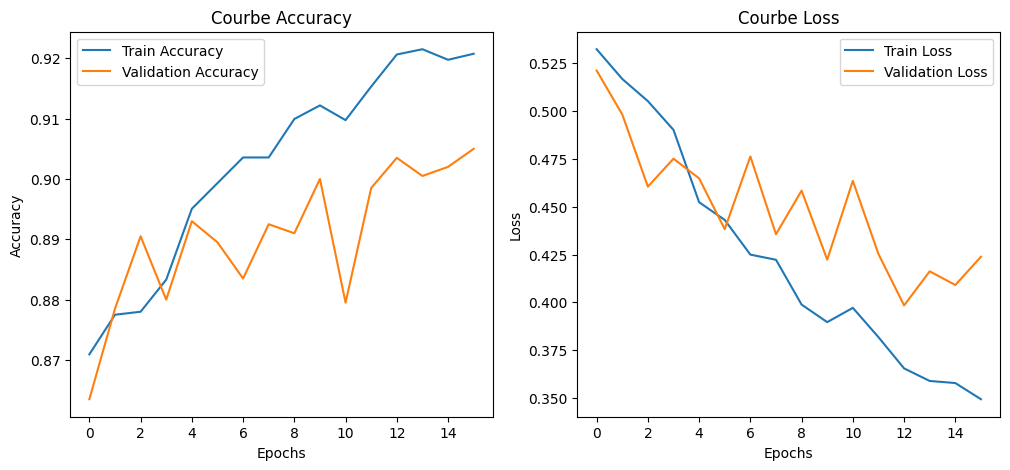

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9018 - loss: 0.4160

Test Accuracy: 0.8985
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       anger       0.90      0.91      0.90       275
        fear       0.87      0.92      0.90       224
         joy       0.92      0.92      0.92       695
        love       0.76      0.79      0.77       159
     sadness       0.93      0.93      0.93       581
    surprise       0.85      0.61      0.71        66

    accuracy                           0.90      2000
   macro avg       0.87      0.84      0.85      2000
weighted avg       0.90      0.90      0.90      2000



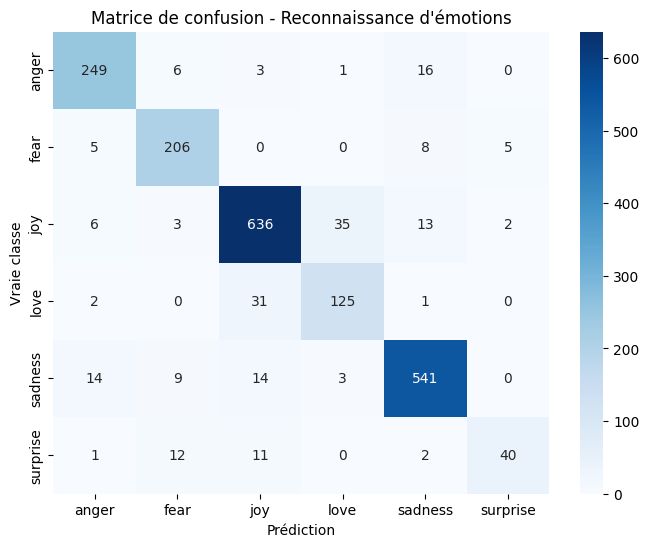

In [10]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_emotion_bilstm.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=128,
    callbacks=callbacks
)
# ====================== COURBES ACCURACY / LOSS ======================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Courbe Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Courbe Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()
# ====================== ÉVALUATION COMPLÈTE ======================

loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc:.4f}")

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Matrice de confusion - Reconnaissance d'émotions")
plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")
plt.show()

In [11]:
model.save("emotion_glove_bilstm.keras")

with open("emotion_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("label2id.pkl", "wb") as f:
    pickle.dump(label2id, f)

with open("id2label.pkl", "wb") as f:
    pickle.dump(id2label, f)

In [12]:
def predict_emotion(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

    pred = model.predict(padded)
    class_id = np.argmax(pred, axis=1)[0]
    confidence = np.max(pred)

    emotion = id2label[class_id]

    print(f"Texte : {text}")
    print(f"Émotion prédite : {emotion}")
    print(f"Confiance : {confidence:.2f}")

    return emotion

predict_emotion("I feel very happy today")
predict_emotion("I am afraid of what will happen")
predict_emotion("I feel so angry right now")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Texte : I feel very happy today
Émotion prédite : joy
Confiance : 1.00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Texte : I am afraid of what will happen
Émotion prédite : fear
Confiance : 0.51
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Texte : I feel so angry right now
Émotion prédite : anger
Confiance : 0.99


'anger'